## Topic

Bias-Variance; Overfitting; Regularization; Linear Regression

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/bias-variance-overfitting-regularization-linear-regression.html)。

## Question

What is Bias-Variance; Overfitting; Regularization; Linear Regression, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Bias-Variance; Overfitting; Regularization; Linear Regression

## Learning Goal

An overly flexible model can fit noise; an overly restricted model misses structure. Ridge penalizes squared coefficients, trading training fit for stability. Regularization strength is selected on validation data, not on the final test.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Change polynomial degree and alpha. Compare training versus validation errors and describe underfitting and overfitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


   degree     train  validation
0       1  0.462480    0.584508
1       3  0.384659    0.421501
2       9  0.058408    0.055772
3      18  0.059115    0.069148


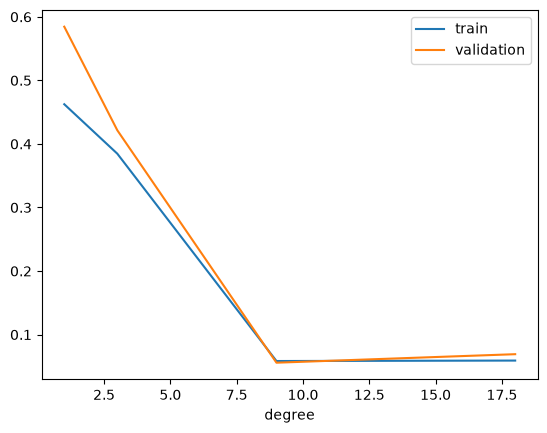

In [2]:
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
rng=np.random.default_rng(7);X=rng.uniform(-2,2,(90,1));y=np.sin(3*X[:,0])+rng.normal(0,.25,90)
rows=[]
for degree in [1,3,9,18]:
    model=make_pipeline(PolynomialFeatures(degree),StandardScaler(),Ridge(alpha=.01)).fit(X[:60],y[:60])
    rows.append([degree,mean_squared_error(y[:60],model.predict(X[:60])),mean_squared_error(y[60:],model.predict(X[60:]))])
result=pd.DataFrame(rows,columns=["degree","train","validation"]);print(result);result.plot(x="degree");plt.show()

## Expected Observations

Training error and validation error need not move together. A single split is noisy; repeated suitable validation gives a more stable comparison.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. An overly flexible model can fit noise; an overly restricted model misses structure. Ridge penalizes squared coefficients, trading training fit for stability. Regularization strength is selected on validation data, not on the final test.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Training error and validation error need not move together. A single split is noisy; repeated suitable validation gives a more stable comparison.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/bias-variance-overfitting-regularization-linear-regression.html)
